# Tinker 2008 HMF emulation

Practicing emulation with the Tinker 2008 mass function.

Steps involved:
 * Figure out what parameters we need to sample over (see what Florian sent then check).
 * Define training function
 * LHC sampling of the parameter space
 * Run those, find a way to save that so limited recalculation??? (Not sure if this is how training is supposed to work)
 * Set up the networks with different shapes
 * Train data runs on those networks
 * The world is my oyster?

In [251]:
from halox import hmf
import jax
import jax.numpy as jnp
import jax_cosmo as jc
from flax import nnx
import optax
import scipy
import matplotlib.pyplot as plt

## Defining the objective

First we need a function to train on, lets write it down in terms of all of the base parameters


In [252]:
@jax.jit
def halox_trainer(x):
    logM, z, omb, omc, h, s8, ns = x
    # Fixed values, maybe incorporate at least delta_c later?
    delta_c = 200
    n_k_int = 5000
    hcosmo = jc.Cosmology(
        Omega_b=omb,
        Omega_c=omc,
        h=h,
        sigma8=s8,
        n_s=ns,
        Omega_k=0,
        w0=-1,
        wa=0,
    )

    M = (
        10**logM
    )  # we are doing this because logM is easier to use in the network???

    return jnp.log10(
        hmf.tinker08_mass_function(
            M, z, cosmo=hcosmo, delta_c=delta_c, n_k_int=n_k_int
        )
    )

## Sampling the parameter space

In [253]:
param_names = ["logM", "z", "omega_b", "omega_c", "sigma8", "h", "n_s"]

bounds = jnp.array(
    [
        [11, 15.3],  # logMass
        [0, 4],  # redshift
        [0.04, 0.06],  # Omega_b
        [0.15, 0.35],  # Omega_c
        [0.7, 0.9],  # sigma8
        [0.6, 0.8],  # h
        [0.9, 1.0],  # n_s
    ]
)

d = bounds.shape[0]
n_samples = 10000 * d

# sampler = scipy.stats.qmc.LatinHypercube(d=d, scramble=True)
# unit_samples = sampler.random(n_samples)
# samples = scipy.stats.qmc.scale(unit_samples, bounds[:,0], bounds[:,1])
# print(samples.shape)

sampler = scipy.stats.qmc.Sobol(d=d, scramble=True)
unit_samples = sampler.random(n_samples)
samples = scipy.stats.qmc.scale(unit_samples, bounds[:, 0], bounds[:, 1])

/tmp/ipykernel_860696/189014652.py:22: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  unit_samples = sampler.random(n_samples)


In [254]:
yv = jax.vmap(halox_trainer)
y_train = yv(samples)

In [255]:
def train_val_split(x, y, val_frac=0.2, seed=1):
    key = jax.random.PRNGKey(seed)
    N = x.shape[0]

    perm = jax.random.permutation(key, N)

    n_val = int(val_frac * N)

    val_idx = perm[:n_val]
    train_idx = perm[n_val:]

    return x[train_idx], y[train_idx], x[val_idx], y[val_idx]

In [256]:
x_train, y_train, x_val, y_val = train_val_split(samples, y_train)

## Helper functions and setting up the network

Note that jax does not have 64 bit precision enabled

In [257]:
def cosmofrmtheta(theta):
    logM, z, omb, omc, s8, h, ns = theta
    return jc.Cosmology(Omega_b=omb, Omega_c=omc, sigma8=s8, h=h, n_s=ns)


nw = 64


class MLP(nnx.Module):
    def __init__(self, rngs: nnx.Rngs):
        self.linear1 = nnx.Linear(7, nw, rngs=rngs)
        self.linear2 = nnx.Linear(nw, nw, rngs=rngs)
        self.linear3 = nnx.Linear(nw, nw, rngs=rngs)
        self.linear4 = nnx.Linear(nw, 1, rngs=rngs)

    def __call__(self, x):
        x = nnx.silu(
            self.linear1(x)
        )  # silu worked WAY better than relu, I wonder why?
        x = nnx.silu(self.linear2(x))
        x = nnx.silu(self.linear3(x))
        x = self.linear4(x)
        return x.squeeze(-1)  # (batch,)


model = MLP(rngs=nnx.Rngs(0))
nnx.display(model)

In [258]:
# Sanity check: pass a few points through the untrained model
sample_input = samples[:5]
sample_output = model(sample_input)
print("Input shape: ", sample_input.shape)
print("Output shape:", sample_output.shape)
print("Output values (untrained):", sample_output)

Input shape:  (5, 7)
Output shape: (5,)
Output values (untrained): [0.83481558 1.10276809 0.86301452 1.01419127 0.51235005]


In [259]:
# %timeit yv(samples)
# %timeit model(samples)

Todo
 * How do I get a good scheduler

In [ ]:
# schedule = optax.warmup_exponential_decay_schedule(
#     init_value=1e-3,
#     peak_value=1e-3,
#     warmup_steps=500,
#     transition_steps=800,
#     decay_rate = 0.9
# )

# schedule = optax.warmup_cosine_decay_schedule(
#     init_value=1e-4,
#     peak_value=1e-3,
#     warmup_steps=2000,
#     decay_steps=30000
# )


# lrs = [schedule(i) for i in range(10_000)]
# plt.plot(range(len(lrs)), lrs)

# LINEAR
# schedule = optax.schedules.linear_schedule(
#     init_value = 1e-2,
#     end_value = 1e-9,
#     transition_steps = 28500,
#     transition_begin = 1500
#     )

# ON PLATEAU (parameters good but needs some modification to optimizer
# to incorporate correctly, (3% on high end only))
plateau = optax.contrib.reduce_on_plateau(
    factor=0.2, cooldown=0, patience=3, accumulation_size=200, rtol=1e-4
)
# Just under 1%, 0.1, 0, 3, 250

tx = optax.chain(optax.adam(1e-2), plateau)


# 0.9, 10, 50
optimizer = nnx.Optimizer(
    model, tx, wrt=nnx.Param
)  # optimizes with respect to nnx.Param


def loss_fn(model, x, y):
    predictions = model(x)
    return jnp.mean((predictions - y) ** 2)


@nnx.jit  # because mutable state
def train_step(model, optimizer, x, y):
    loss, grads = nnx.value_and_grad(loss_fn)(
        model, x, y
    )  # returns new values, not in place replacement
    optimizer.update(
        grads, value=loss
    )  # only grads is needed here, is this backprop
    return loss

In [261]:
n_epochsv2 = 30_000
lossesv2 = []
val = []
val_epochs = []
lr_history = []

for epoch in range(n_epochsv2):
    loss = train_step(model, optimizer, x_train, y_train)
    lossesv2.append(float(loss))

    state = optimizer.opt_state

    # plateau transform is the last transform in the chain
    plateau_state = state[-1]

    lr = 0.005 * plateau_state.scale

    lr_history.append(lr)

    if epoch % 500 == 0 or epoch == n_epochsv2 - 1:
        val.append(loss_fn(model, x_val, y_val))
        val_epochs.append(epoch)
        print(f"Epoch {epoch:>5d} | Loss: {loss:.6f}")

Epoch     0 | Loss: 142.720019
Epoch   500 | Loss: 1.522358
Epoch  1000 | Loss: 1.406010
Epoch  1500 | Loss: 0.450568
Epoch  2000 | Loss: 0.381369
Epoch  2500 | Loss: 0.254883
Epoch  3000 | Loss: 0.438819
Epoch  3500 | Loss: 0.476273
Epoch  4000 | Loss: 0.198413
Epoch  4500 | Loss: 0.170185
Epoch  5000 | Loss: 0.470407
Epoch  5500 | Loss: 0.339305
Epoch  6000 | Loss: 0.143582
Epoch  6500 | Loss: 0.468528
Epoch  7000 | Loss: 0.031533
Epoch  7500 | Loss: 0.365697
Epoch  8000 | Loss: 0.294489
Epoch  8500 | Loss: 0.176875
Epoch  9000 | Loss: 0.178743
Epoch  9500 | Loss: 0.093560
Epoch 10000 | Loss: 0.096778
Epoch 10500 | Loss: 0.139595
Epoch 11000 | Loss: 0.011465
Epoch 11500 | Loss: 0.052614
Epoch 12000 | Loss: 0.089976
Epoch 12500 | Loss: 0.292462
Epoch 13000 | Loss: 0.015457
Epoch 13500 | Loss: 0.001620
Epoch 14000 | Loss: 0.001200
Epoch 14500 | Loss: 0.000949
Epoch 15000 | Loss: 0.000775
Epoch 15500 | Loss: 0.000646
Epoch 16000 | Loss: 0.000595
Epoch 16500 | Loss: 0.000564
Epoch 17000 

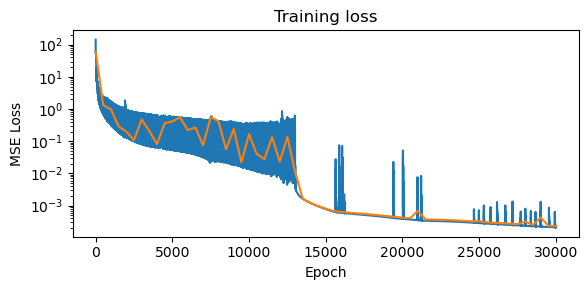

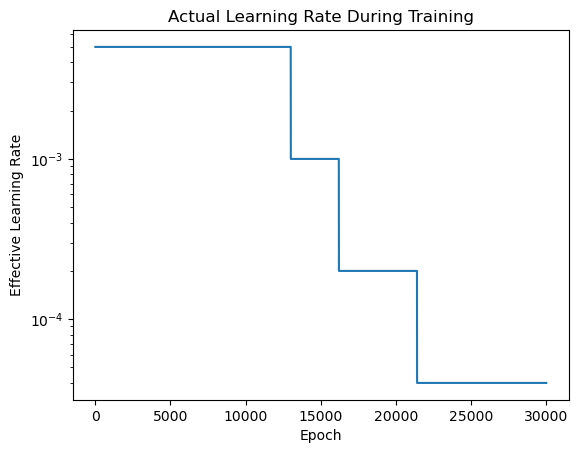

In [262]:
val = jnp.array(val)

fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(lossesv2)
ax.semilogy(val_epochs, val)
ax.set(xlabel="Epoch", ylabel="MSE Loss", title="Training loss")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(lr_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Effective Learning Rate")
plt.title("Actual Learning Rate During Training")
plt.show()

(14000, 7)


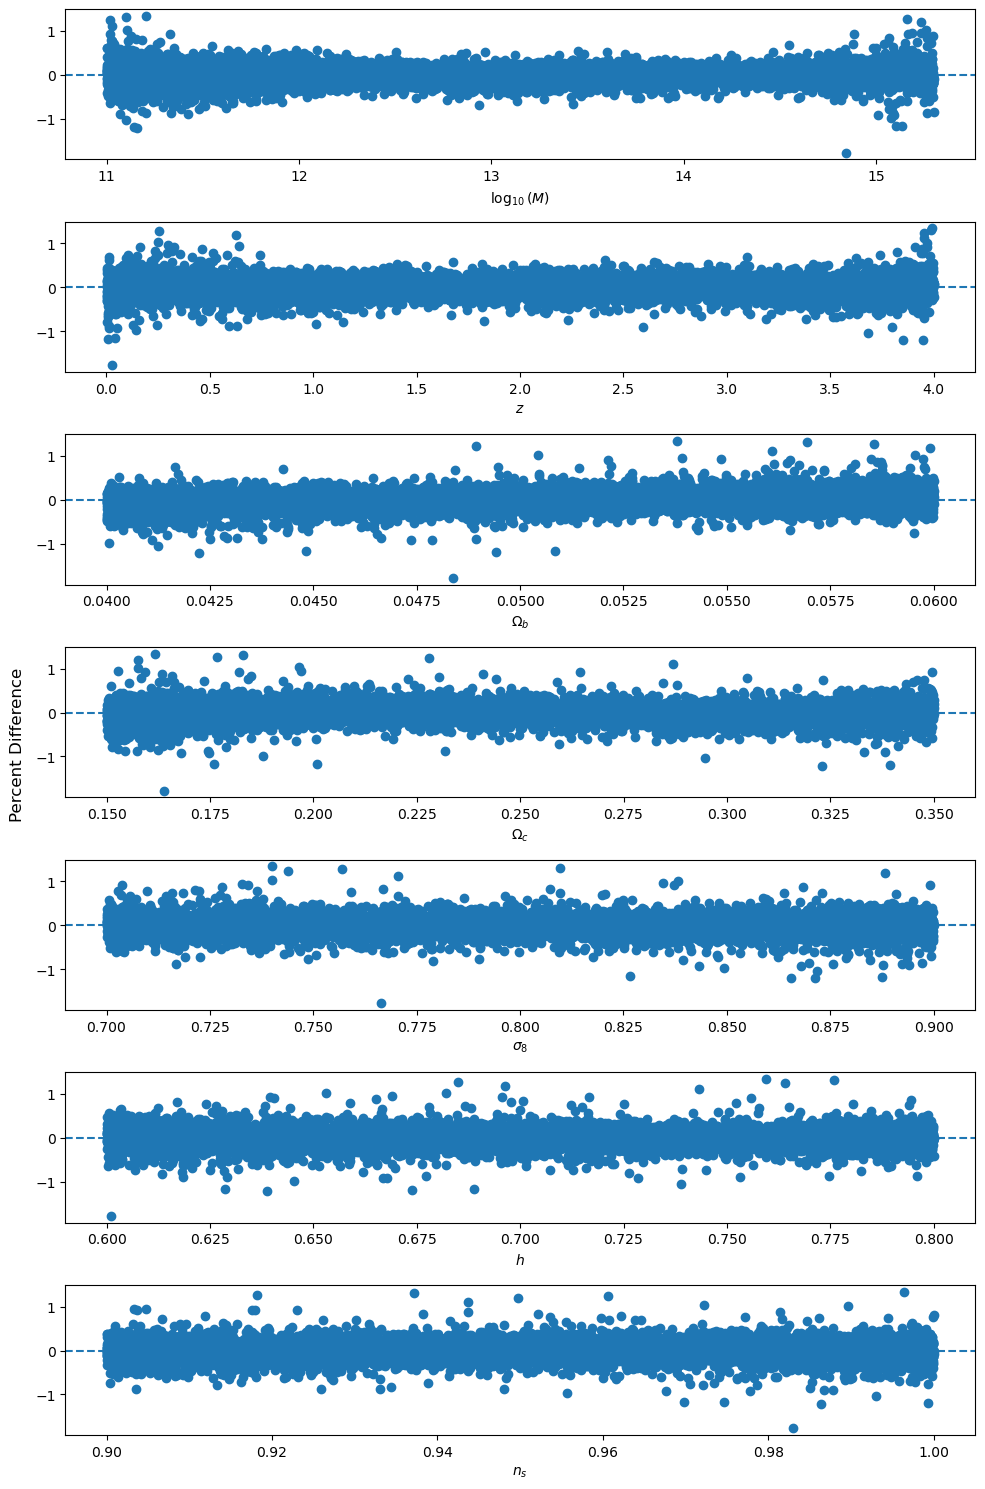

In [273]:
prediction = model(x_val)
residual = (prediction - y_val) / y_val * 100

print(x_val.shape)

fig, [ax1, ax2, ax3, ax4, ax5, ax6, ax7] = plt.subplots(7, figsize=(10, 15))
ax1.axhline(0, linestyle="--")
ax1.scatter(x_val[:, 0], residual)
ax1.set_xlabel(r"$\log_{10}(M)$")

ax2.axhline(0, linestyle="--")
ax2.scatter(x_val[:, 1], residual)
ax2.set_xlabel(r"$z$")

ax3.axhline(0, linestyle="--")
ax3.scatter(x_val[:, 2], residual)
ax3.set_xlabel(r"$\Omega_b$")

ax4.axhline(0, linestyle="--")
ax4.scatter(x_val[:, 3], residual)
ax4.set_xlabel(r"$\Omega_c$")

ax5.axhline(0, linestyle="--")
ax5.scatter(x_val[:, 4], residual)
ax5.set_xlabel(r"$\sigma_8$")

ax6.axhline(0, linestyle="--")
ax6.scatter(x_val[:, 5], residual)
ax6.set_xlabel(r"$h$")

ax7.axhline(0, linestyle="--")
ax7.scatter(x_val[:, 6], residual)
ax7.set_xlabel(r"$n_s$")

fig.supylabel("Percent Difference")
fig.tight_layout()

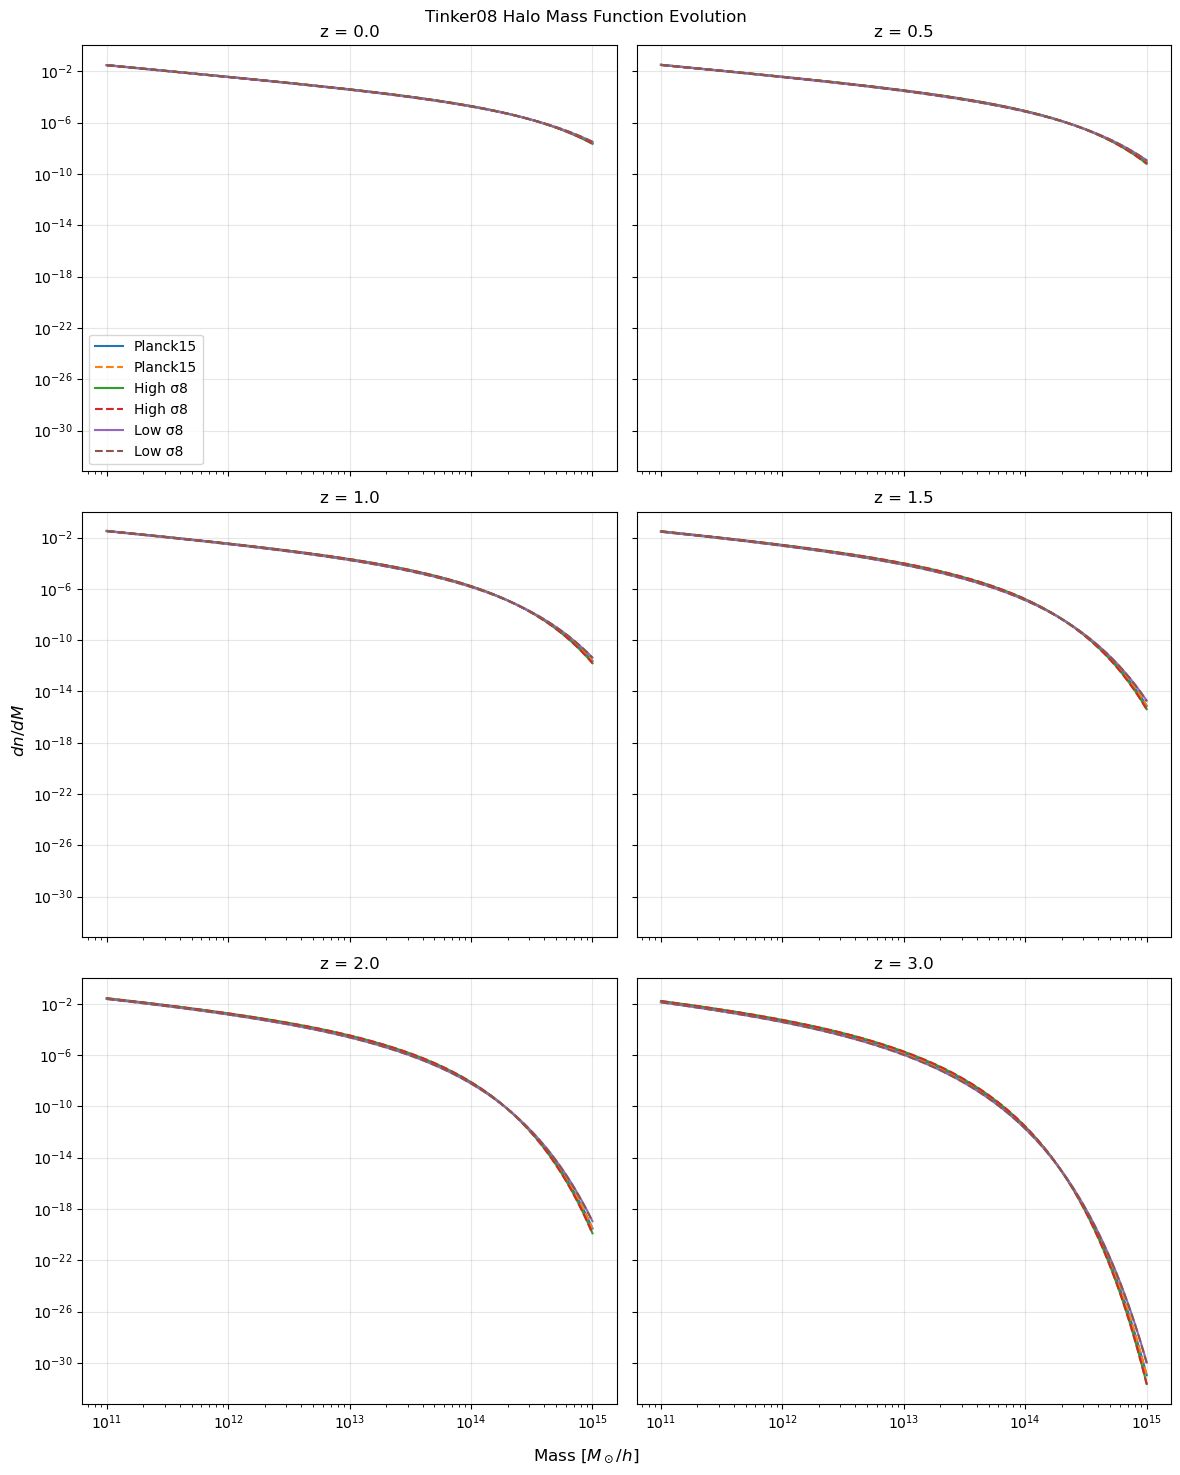

In [264]:
cosmo_fid = jc.Planck15()

cosmo_high_s8 = jc.Cosmology(
    Omega_b=cosmo_fid.Omega_b,
    Omega_c=cosmo_fid.Omega_c,
    h=cosmo_fid.h,
    sigma8=0.9,
    n_s=cosmo_fid.n_s,
    Omega_k=0,
    w0=-1,
    wa=0,
)

cosmo_low_s8 = jc.Cosmology(
    Omega_b=cosmo_fid.Omega_b,
    Omega_c=cosmo_fid.Omega_c,
    h=cosmo_fid.h,
    sigma8=0.7,
    n_s=cosmo_fid.n_s,
    Omega_k=0,
    w0=-1,
    wa=0,
)

cosmologies = [
    ("Planck15", cosmo_fid),
    ("High σ8", cosmo_high_s8),
    ("Low σ8", cosmo_low_s8),
]

masses = jnp.logspace(11, 15, 256)
zs = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]

halox_mass_vmap = jax.vmap(halox_trainer)


def build_input(masses, z, cosmo):
    logM = jnp.log10(masses)

    return jnp.column_stack(
        [
            logM,
            jnp.full_like(logM, z),
            jnp.full_like(logM, cosmo.Omega_b),
            jnp.full_like(logM, cosmo.Omega_c),
            jnp.full_like(logM, cosmo.sigma8),
            jnp.full_like(logM, cosmo.h),
            jnp.full_like(logM, cosmo.n_s),
        ]
    )


fig, axes = plt.subplots(3, 2, figsize=(12, 15), sharex=True, sharey=True)
axes = axes.flatten()

for ax, z in zip(axes, zs):
    for label, cosmo in cosmologies:
        x = build_input(masses, z, cosmo)
        log_hmf_nn = model(x)
        log_hmf = halox_mass_vmap(x)

        ax.plot(masses, 10**log_hmf, label=label)
        ax.plot(masses, 10**log_hmf_nn, label=label, linestyle="--")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"z = {z}")
    ax.grid(alpha=0.3)

axes[0].legend()

fig.supxlabel("Mass [$M_\odot/h$]")
fig.supylabel(r"$dn/dM$")
fig.suptitle("Tinker08 Halo Mass Function Evolution")

plt.tight_layout()
plt.show()

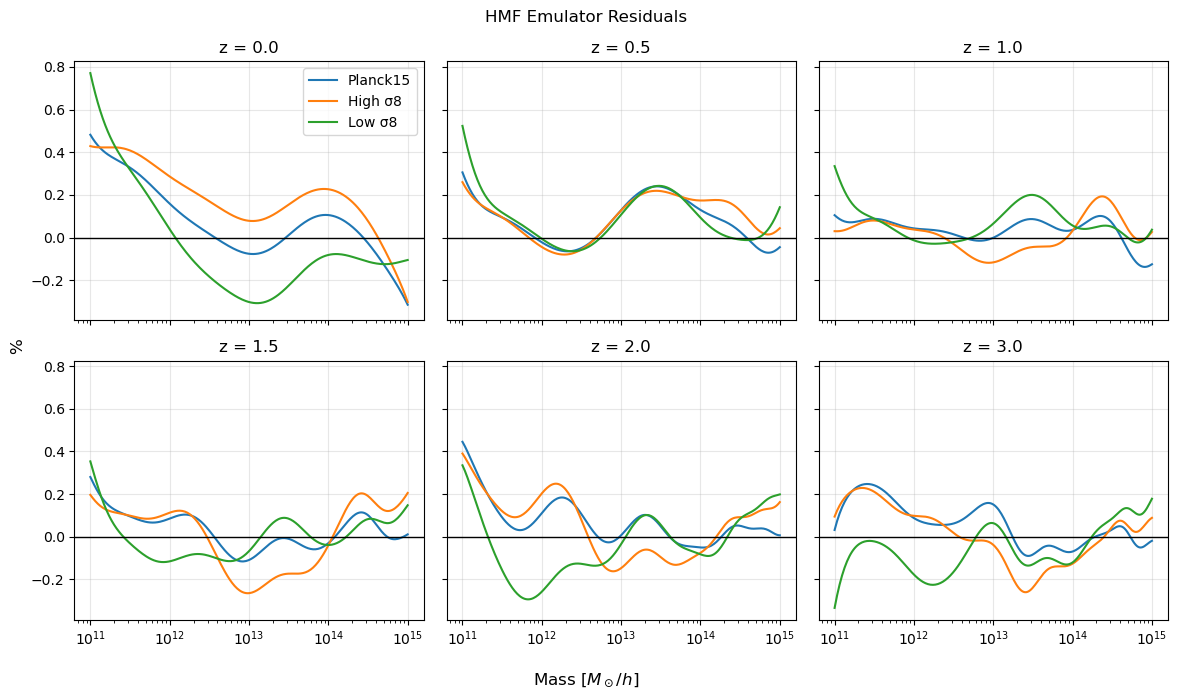

In [271]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True)
axes = axes.flatten()

for ax, z in zip(axes, zs):
    for label, cosmo in cosmologies:
        x = build_input(masses, z, cosmo)

        log_hmf_nn = model(x)
        log_hmf_true = halox_mass_vmap(x)

        residual = (
            (log_hmf_nn - log_hmf_true) / log_hmf_true
        ) * 100  # dex residual
        ax.plot(masses, residual, label=label)

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xscale("log")
    ax.set_title(f"z = {z}")
    ax.grid(alpha=0.3)

axes[0].legend()

fig.supxlabel("Mass [$M_\odot/h$]")
fig.supylabel(r"%")
fig.suptitle("HMF Emulator Residuals")

plt.tight_layout()
plt.show()